# Warsaw Public Transport Analysis for Pizza Brand Expansion
**By Sasha Fridman, March 2025**

<hr style="border: none; border-top: 2.5px solid black;">

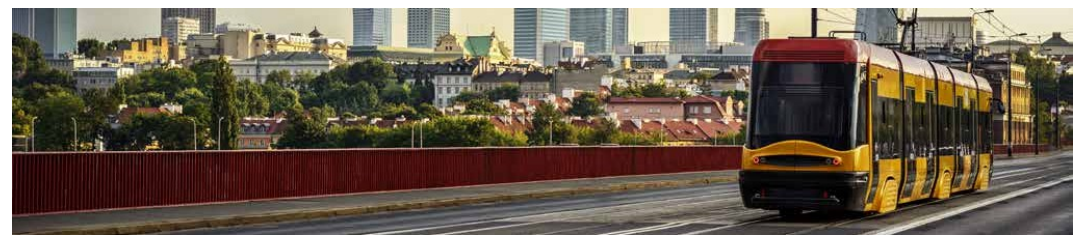

## 📖 Project Description

### 👁️ Project Overview

**The goal of this project is to analyze Warsaw's public transportation network** to help a global pizza brand identify optimal locations for opening new pizzerias. **We aim to identify the busiest transport hubs - areas with high passenger flow**. We will independently source the necessary data *(as no specific data is available at the start).*

***Note 1: The focus will be primarily on non-central stations** *(as their popularity and traffic are evident)*, though we may include central stations in our analysis as well.*  
***Note 2: Public transport will be the main focus of this study** *(being one of the layers in decision-making for opening new pizza locations)*. Additionally, **we may complement the analysis with other types of people flows**, such as private car traffic, if reliable data is available.*

### 📋 Project Terminology and Notations

- **Key terms**. To ensure clarity in our analysis, we will **define several key terms** upfront:

    - **Geospatial data** - in general, is **information that has a geographic component and can be linked to specific locations** on the Earth's surface *(for instance, details about places, addresses, and coordinates).* **In current project we mostly refer to geospatial data as for coordinates - latitude and longitude of data points like transport stops.**
    -  **GTFS dataset** - GTFS (General Transit Feed Specification) is **a standardized format for sharing data about public transit schedules**, which in fact is **a set of related files zipped together**.
    -  **Headway** - **time between vehicle departures**, in other words it's **wait time**. Headway is applicable for routes with frequency-based scheduling.
    -  **Weighted Trips Capacity** - **a metric that estimates passenger flows at each stop by accounting for both the number of public transport trips and the passenger capacity of each transport type**. Simply counting raw trips would be misleading, so trips are adjusted based on transport capacity. For example, a bus (base unit) has a weight of 1 (~ 90 passengers), while a tram has a weight of 2.2 (~200 passengers). **This approach provides a more accurate impact calculations for different transport types on passenger flows across stops**.
      
      
- **Symbols**. There are also **several symbols we use in the project to highlight key points**: 

    - 💡 - **An important insight** relevant to this specific part of the study.      
    - 💡💡 - **A key insight** with significant implications for the entire project.    
    - ⚠ - **Information  requiring special attention** (e.g., major clarifications, major conclusions or decision explanations), as it may impact further analysis.
    
        ***Additional clarifications** with more local relevance are preceded by the bold word ****"Note"** and/or highlighted in italics.***      

### 📋 Data Sources and Description

1. **GTFS Data (`warsaw.zip`):** A dataset providing static information about Warsaw's public transportation system.

    -   **`agency.txt`:** Information about the transit agencies managing Warsaw's public transport (e.g., name, contact details).
        
    -   **`attributions.txt`:** Specifies whether an organization is a data producer, operator, or authority.
    -   **`calendar_dates.txt`:** Information about service availability on special days - exceptions to the standard schedule, such as holidays.
    -   **`feed_info.txt`:** Metadata about the dataset (e.g., publisher name, website, and feed version).
    -   **`frequencies.txt`:** Specifies headway (time between vehicle departures) for routes with frequency-based scheduling.
    -   **`routes.txt`:** Details about the routes served by each transit agency (route ID, name, type).
    -   **`shapes.txt`:** Describes the exact paths taken by vehicles along a route (latitude, longitude), Essential for visualizing transit flow on a map.
    -   **`stops.txt`:** Locations of bus stops, tram stops, and metro stations (stop ID, name, latitude, longitude).    
    -   **`stop_times.txt`:** Arrival and departure times for each trip at each stop (trip ID, stop ID, arrival time, departure time, stop sequence).  ***This file is the core for our passenger flow analysis***.
    -   **`trips.txt`:** Individual trips along each route (trip ID, route ID, service ID).  

      
    ***Note 1:***  *The **GTFS feed** is available at https://mkuran.pl/gtfs/warsaw.zip (maintained by Mikołaj Kuranowski, a developer dedicated to enhancing public transportation data accessibility in Poland). The **source of data - Zarząd Transportu Miejskiego (ZTM)** also known as **Warsaw Public Transport (WTP)***. *Data last updated at January 18, 2025*.
       
    At the time of this study, the official website of **Warsaw Public Transport** ([wtp.waw.pl](https://www.wtp.waw.pl/en/public-transport-in-warsaw/)) was experiencing technical difficulties (**403 ERROR - Request Blocked**). Thus, we relied on the **`warsaw.zip` dataset from mkuran.pl**, which provides sufficient data for analysis.
   
   ***Note 2:*** *Since `warsaw.zip` is ~ 90MB (~ 606 MB after extraction), we use a script to automate downloading and extracting the file when needed (instead of loading it directly when sharing e.g. via GitHub)*   

   ***Note 3:*** *While this **feed offers comprehensive data on Warsaw's public transportation system, it doesn't not include specific data such as passenger counts**. In other words **it focuses on transit schedules**, not real-time passenger load data. However, **relying on Warsaw's transportation management decisions** (supported by public reports and citizen surveys), **this approach should effectively highlight main traffic spots, which will be sufficient for the current study***
  
   *If requested for more precise analysis **in the next steps we may access the [Warsaw open data portal](https://api.um.warszawa.pl/) to gain insight on the online data as well.***

## 📚 Loading Data and Libraries

In [8]:
# data manipulation libraries
import pandas as pd
import numpy as np
import sidetable
import requests
import zipfile
import io
import os

# date and time handling
from datetime import datetime, timedelta

# handling geo-data
%pip install gtfs_kit -q
%pip install geopy -q

# a stable and widely compatible version
%pip install folium==0.17.0 -q 

import gtfs_kit as gk
from gtfs_kit import Feed
from geopy.distance import geodesic

# visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter, EngFormatter
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio # tools for saving and exporting and visualizations
import folium
from folium.plugins import HeatMap
from folium.plugins import MarkerCluster

# Matplotlib and Seaborn visualization configuration
plt.style.use('seaborn-v0_8')  # more attractive styling
plt.rcParams.update({
    'figure.figsize': (12, 7),  
    'grid.alpha': 0.5,
    'grid.linestyle': '--',
    'font.size': 8,
    'axes.titlesize': 14,
    'axes.labelsize': 10})
sns.set_theme(style="whitegrid", palette="deep")

# Pandas display options
# pd.set_option('display.max_columns', None)
table_width = 150
# pd.set_option('display.width', table_width)
col_width = 40
# pd.set_option('display.max_colwidth', col_width)
# pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format) # displaying normal numbers instead of scientific notation

# Python and Jupyter/IPython utility libraries and settings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all' # notebook enhanced output
from IPython.display import display, HTML, Markdown  # broader options for text formatting and displaying
import textwrap # for formatting and wrapping text (e.g. to manage long strings in outputs)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 🚌 Warsaw Public Transport Overview

- **Components:**
    - **Metro (2 lines):** As of 2024, the Warsaw Metro comprises two lines (M1 and M2) with a total of 39 stations, covering approximately 41 kilometers.       
    - **Trams (24 lines):** The tram network consists of 24 lines, serving 538 stops.    
    - **Buses:** The bus system operates 301 lines, including over 200 daytime routes and 41 nighttime routes, covering 3,227 stops.      
    - **Urban Railway (SKM - Szybka Kolej Miejska):** This urban rapid transit system operates 9 lines with 198 stations, facilitating connections within Warsaw.      
    - **Regional Rail (KM - Koleje Mazowieckie):** Serving the broader Mazovia region, KM operates regional rail services with 45 stations within Warsaw's city limits.       
    - **Warsaw Commuter Railway (WKD - Warszawska Kolej Dojazdowa):** WKD operates on a separate railway line, serving commuters traveling between Warsaw and its southwestern suburbs.
      
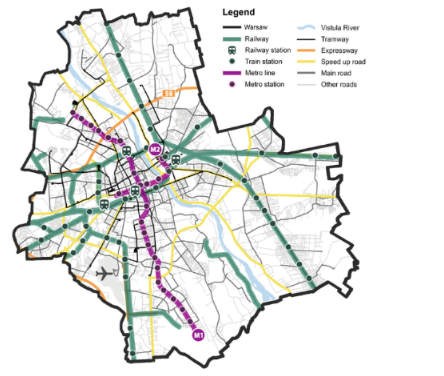


- **Annual passenger flow** *(actual for 2022)*: 
    - The **annual passenger flow is approximately 863 million**, with **buses (403 M)** and **trams (247 M)** handling the majority of passengers. **Metro** accounts for **161 M passengers**, while **rail** services handle **~53 million combined**. The detailed numbers are following:
        - **Metro:** 160.8 M (**18.6%** of total volume)  
        - **Trams:** 247.2 M (**28.6%** of total volume)   
        - **Buses:** 403 M (**46.7%** of total volume) 
        - **Urban Railway (SKM):** 17.8 M (**2.1%** of total volume) 
        - **Regional Rail (KM within city limits):** 31 M (**3.6%** of total volume)  
        - **Warsaw Commuter Railway (WKD):** 3.7 M (**0.4%** of total volume)- 
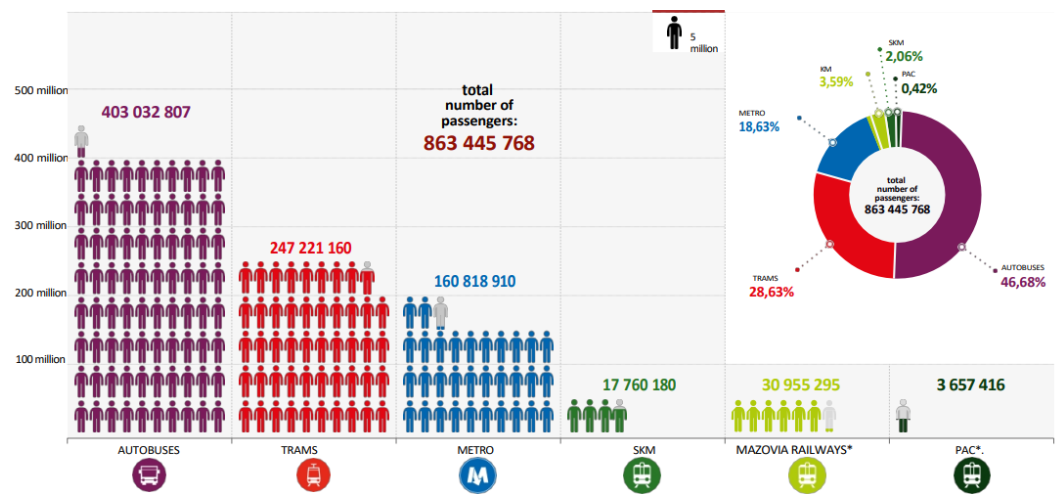


- **Useful details and insights:**
    - **The network is managed by ZTM (Zarząd Transportu Miejskiego - Public Transport Authority)**, which handles tickets, schedules and infrastructure.
    -  On weekdays, more than 1,500 buses, 400 streetcars, 62 subway trains and 19 units of the Rapid Urban Rail (SKM) are directed to service lines. The transportation network in Warsaw is about 3,600 kilometers, and outside the capital about 1,400 kilometers. **In 2022, public transportation carried 863,445,768 passengers.**
    - The transportation trends have shifted after COVID-19, but **by 2023, passenger numbers returned to pre-pandemic levels with some changed patterns** (more weekend travel, slightly different peak hours).

- **Recent developments (since 2020):**
    - **Expanded the M2 metro line** to east side
    - Implemented **more bus lanes**
    - **Integrated the system with mobile apps for real-time passengers tracking**

- **Development plans:**
    - **Two new metro lines M3 and M4 are planned**.
    - **Construction of the M3 line will begin in 2028, no clear date for start of M4 revealed.**
    - In 2030, the M3 (shorter route) is expected to carry about 315 thousand passengers per day.
    - According to preliminary assumptions, the M4 line will be 26 km long and have 23 stations, including 2 common for the M4/M2 and M4/M3 lines. There will be several transfer hubs on its route to metro lines M1 (Marymont station), M2 (Rondo Daszyńskiego), M3 (Żwirki i Wigury) and M5 (Plac Narutowicza), as well as to surface public transport and railway lines.   

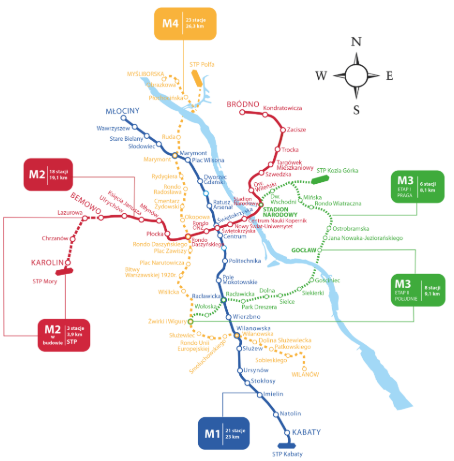


In [11]:
# downloading the file
url = 'https://mkuran.pl/gtfs/warsaw.zip'
response = requests.get(url)

# creating a ZipFile object from the downloaded content. Originally it is in bytes format, so we convert it in io.BytesIO to simulate a file-like object that zipfile can read from memory
z = zipfile.ZipFile(io.BytesIO(response.content))

# extracting to a directory if it doesn't exist
extract_dir = 'warsaw_gtfs'
os.makedirs(extract_dir, exist_ok=True) # if the directory already exists, an error won't appear
z.extractall(extract_dir)

# displaying the list of extracted files 
files = os.listdir(extract_dir)
print(f'Extracted files: {files}')

Extracted files: ['agency.txt', 'attributions.txt', 'calendar_dates.txt', 'feed_info.txt', 'frequencies.txt', 'routes.txt', 'shapes.txt', 'stops.txt', 'stop_times.txt', 'trips.txt']


## 🧹 Data Preprocessing 

### 👁️ Initial Data Overview

#### 📐 Enriching Our Analysis Toolkit

Let's enhance efficiency of our further analysis by creating two functions: `get_df_name` and `data_inspection`.

**Function: `get_df_name`**

The `get_df_name` function **retrieves and returns the name of a DataFrame** variable as a string, what will be handy for displaying information explicitly by other functions.

In [16]:
def get_df_name(df):
    """
    The function returns the user-defined name of the DataFrame variable as a string.

    Input: the DataFrame whose name must be extracted.
    Output: the name of the DataFrame.
    """
    
    for name, value in globals().items():
        if value is df:
            if not name.startswith('_'): # excluding internal names
                return name   
    return "name not found"

**Function: `data_inspection`**

The `data_inspection` function **performs comprehensive inspections of a given DataFrame**. It provides insights into the dataset's structure, including concise summaries, examples, descriptive statistics, categorical parameter statistics, missing values, and duplicates.

In [18]:
def data_inspection(df, show_example=True, example_type='head', example_limit=5, frame_len=120):
    """
    The function performs various data inspections on a given DataFrame.
    
    As input it takes:
        - df: a DataFrame to be evaluated.     
        - show_example (bool, optional): whether to display examples of the DataFrame. By default - True.
        - example_type (str, optional): type of examples to display ('sample', 'head', 'tail'). By default - 'head'.
        - example_limit (int, optional): maximum number of examples to display. By default - 5.
        - frame_len (int, optional): the length of frame of printed outputs. Default - 40.
        - frame_len (int, optional): the length of frame of printed outputs. Default - 40. If `show_example` is True, frame_len is set to minimum of the values: manually set `frame_len` and `table_width (which is defined at the project initiation stage).

    As output it presents: 
        - Displays concise summary.
        - Displays examples of the `df` DataFrame (if `show_example` is True)
        - Displays descriptive statistics.
        - Displays descriptive statistics for categorical parameters.
        - Displays information on missing values.
        - Displays information on dublicates.
    """  

    # adjusting output frame; "table_width" is set at project initiation stage
    frame_len = min(table_width, frame_len) if show_example else frame_len
    
    # retrieving a name of the DataFrame
    df_name = get_df_name(df)
    
    # calculating figures on duplicates
    dupl_number = df.duplicated().sum()
    dupl_share = round(df.duplicated().mean()*100, 1)

    # displaying information about the DataFrame
    print('='*frame_len)
    display(Markdown(f'**Overview of `{df_name}`:**'))
    print('-'*frame_len)
    print(f'\033[1mConcise summary:\033[0m')
    print(df.info(), '\n')
    
    if show_example: 
        print('-'*frame_len)
        example_messages = {'sample': 'Random examples', 'head': 'Top rows', 'tail': 'Bottom rows'}
        example_methods = {'sample': df.sample, 'head': df.head, 'tail': df.tail}         
        message = example_messages.get(example_type)       
        method = example_methods.get(example_type)        
        print(f'\033[1m{message}:\033[0m')
        print(method(min(example_limit, len(df))), '\n')      
        
    print('-'*frame_len)
    print(f'\033[1mDescriptive statistics:\033[0m') 
    print(df.describe(), '\n')
    print('-'*frame_len)
    print(f'\033[1mDescriptive statistics of categorical parameters:\033[0m') 
    print(df.describe(include=['object']), '\n')  # printing descriptive statistics for categorical parameters
    
    print('-'*frame_len)
    print(f'\033[1mMissing values:\033[0m') 
    display(df.stb.missing(style=True))
    
    print('-'*frame_len)
    print(f'\033[1mNumber of duplicates\033[0m: {dupl_number} ({dupl_share :.1f}% of all entries)\n')    
    print('='*frame_len)

#### 🔍 Initial Data Examination

In [20]:
# reading the key files and transforming them into DataFrames
stops_df = pd.read_csv(f'{extract_dir}/stops.txt')
routes_df = pd.read_csv(f'{extract_dir}/routes.txt')
trips_df = pd.read_csv(f'{extract_dir}/trips.txt', low_memory=False) # forcing Pandas to read the entire file into memory at once, avoiding DtypeWarnings 
stop_times_df = pd.read_csv(f'{extract_dir}/stop_times.txt', low_memory=False)
frequencies_df = pd.read_csv(f'{extract_dir}/frequencies.txt') 
calendar_dates_df = pd.read_csv(f'{extract_dir}/calendar_dates.txt')

In [21]:
# examination of the main DataFrames 
main_dataframes = [stops_df, routes_df, trips_df, stop_times_df, frequencies_df, calendar_dates_df]

for df in main_dataframes:
    data_inspection(df, show_example=True, example_type='sample', example_limit=5, frame_len=120)

**Overview of `stops_df`:**

------------------------------------------------------------------------------------------------------------------------
Concise summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7107 entries, 0 to 7106
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   stop_id              7107 non-null   object 
 1   stop_name            7107 non-null   object 
 2   stop_code            6792 non-null   object 
 3   platform_code        2 non-null      object 
 4   stop_lat             7107 non-null   float64
 5   stop_lon             7107 non-null   float64
 6   location_type        7107 non-null   int64  
 7   parent_station       292 non-null    object 
 8   wheelchair_boarding  7107 non-null   int64  
 9   stop_name_stem       6777 non-null   object 
 10  town_name            6777 non-null   object 
 11  street_name          6713 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 6

,missing,total,percent
platform_code,"7,105","7,107",99.97%
parent_station,"6,815","7,107",95.89%
street_name,394,"7,107",5.54%
stop_name_stem,330,"7,107",4.64%
town_name,330,"7,107",4.64%
stop_code,315,"7,107",4.43%
stop_id,0,"7,107",0.00%
stop_name,0,"7,107",0.00%
stop_lat,0,"7,107",0.00%
stop_lon,0,"7,107",0.00%


------------------------------------------------------------------------------------------------------------------------
Number of duplicates: 0 (0.0% of all entries)



**Overview of `routes_df`:**

...

------------------------------------------------------------------------------------------------------------------------
Number of duplicates: 0 (0.0% of all entries)



**Overview of `calendar_dates_df`:**

------------------------------------------------------------------------------------------------------------------------
Concise summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            62 non-null     int64 
 1   service_id      62 non-null     object
 2   exception_type  62 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.6+ KB
None 

------------------------------------------------------------------------------------------------------------------------
Random examples:
        date      service_id  exception_type
16  20250504  2025-04-13:NdS               1
56  20250425             PtM               1
5   20250502  2025-04-11:PtS               1
59  20250412             SbM               1
20  20250415  2025-04-15:PcS               1 

-------------------------------------------------------------------------

,missing,total,percent
date,0,62,0.00%
service_id,0,62,0.00%
exception_type,0,62,0.00%


------------------------------------------------------------------------------------------------------------------------
Number of duplicates: 0 (0.0% of all entries)



In [22]:
# checking unique values and their count of each main DataFrame and each column 
for df in main_dataframes:
    display(Markdown(f'**`{get_df_name(df)}`**'))
    for parameter in df.columns:
        print('='*100)
        print(f'\033[1m`{parameter}`\033[0m')
        df[parameter].value_counts()
    print()    

**`stops_df`**

`stop_id`


stop_id
100101    1
406404    1
406901    1
406806    1
406804    1
         ..
221201    1
221102    1
221101    1
221002    1
7903      1
Name: count, Length: 7107, dtype: int64

`stop_name`


stop_name
1                      37
2                      37
3                      33
4                      31
5                      28
                       ..
Młochów Platanowa       1
Młochów Leśniczówka     1
Krakowiany              1
Wola Krakowiańska       1
Warszawa Gdańska        1
Name: count, Length: 2890, dtype: int64

...

date
20250409    2
20250504    2
20250424    2
20250417    2
20250507    2
20250430    2
20250423    2
20250416    2
20250506    2
20250429    2
20250422    2
20250415    2
20250505    2
20250428    2
20250414    2
20250503    2
20250410    2
20250501    2
20250427    2
20250421    2
20250420    2
20250413    2
20250426    2
20250419    2
20250412    2
20250509    2
20250502    2
20250425    2
20250418    2
20250411    2
20250508    2
Name: count, dtype: int64

`service_id`


service_id
PcM               16
2025-04-13:NdS     7
NdM                7
2025-04-11:PtS     5
PtM                5
2025-04-15:PcS     4
2025-04-16:PcS     4
2025-04-12:SbS     3
2025-04-14:PcS     3
2025-04-17:PcS     3
SbM                3
2025-04-09:PcS     1
2025-04-10:PcS     1
Name: count, dtype: int64

`exception_type`


exception_type
1    62
Name: count, dtype: int64

**Consistent match between `stop_id` and `stop_name`** *(lack of cases where one `stop_id` value has multiple `stop_name` values or vice versa)* **is crucial for our study**. Let's examine it these connections. 

In [24]:
# checking that each `stop_id` has only one unique `stop_name` and vice versa
print(f'\033[1mChecking number of stop names for each stop id\033[0m (data is sorted):')
stops_df.groupby('stop_id')['stop_name'].value_counts().sort_values()

print(f'\n\033[1mChecking number of stop ids for each stop name\033[0m (data is sorted):')
stops_df.groupby('stop_name')['stop_id'].value_counts().sort_values()

Checking number of stop names for each stop id (data is sorted):


stop_id  stop_name       
100101   Kijowska            1
406806   Sękocin-Las         1
406804   Sękocin-Las         1
406802   Sękocin-Las         1
406801   Sękocin-Las         1
                            ..
221101   Peonii              1
221002   Jeziorowa           1
221001   Jeziorowa           1
221501   Wodniaków           1
7903     Warszawa Gdańska    1
Name: count, Length: 7107, dtype: int64


Checking number of stop ids for each stop name (data is sorted):


stop_name                               stop_id 
1                                       1003M:E1    1
Poleczki                                301302      1
                                        301301      1
Pole Mokotowskie                        3228M:P1    1
                                        3228M       1
                                                   ..
Konstancin-Jeziorna CH Stara Papiernia  318501      1
Konstancin-Jeziorna Bydgoska            322352      1
Konstancin-Jeziorna Borowa              330402      1
Konstancin-Jeziorna Dolna               371301      1
Żółkiewskiego                           201204      1
Name: count, Length: 7107, dtype: int64

In [25]:
# checking `stop_id` values presence
print(f'\033[1mUnique `stop_id` values:\033[0m')
print(' - `stops_df`:', stops_df['stop_id'].nunique())
print(' - `stop_times_df`:', stop_times_df['stop_id'].nunique())

common_stop_ids = set(stops_df['stop_id']).intersection(stop_times_df['stop_id'])
print(f"\n\033[1mNumber of common `stop_id` values in `stops_df' and `stop_times_df` :\033[0m {len(common_stop_ids)}")

stop_times_stops_list = stop_times_df['stop_id'].unique()
excluded_stops = stops_df.query('stop_id not in @stop_times_stops_list')

print(f'\n\033[1mExcluded stops:\033[0m {len(excluded_stops["stop_id"])} ({len(excluded_stops["stop_id"]) / stops_df["stop_id"].nunique() :0.1%} of total)')

print('\n\033[1mSample of excluded stops:\033[0m')
print(excluded_stops.sample(3, random_state=7))

Unique `stop_id` values:
 - `stops_df`: 7107
 - `stop_times_df`: 6816

Number of common `stop_id` values in `stops_df' and `stop_times_df` : 6816

Excluded stops: 291 (4.1% of total)

Sample of excluded stops:
       stop_id         stop_name stop_code platform_code  stop_lat  stop_lon  \
5463  5034M:E7                 7       NaN           NaN     52.24     20.91   
673      1231M  Stadion Narodowy       C14           NaN     52.25     21.04   
3335  3127M:E1                 1       NaN           NaN     52.16     21.03   

      location_type parent_station  wheelchair_boarding stop_name_stem  \
5463              2          5034M                    1            NaN   
673               1            NaN                    1            NaN   
3335              2          3127M                    1            NaN   

     town_name street_name  
5463       NaN         NaN  
673        NaN         NaN  
3335       NaN         NaN  


<span style="font-size:1.19em;"><b>Observations</b></span> 

- **stops_df (`stops.txt`)**
    - **7,107 stops**, as expected, most concentrated in **Warszawa (4,343 stops)**, while some neighborhoods are also covered, e.g. Legionowo (92 stops)
    - **Platform codes (99.97%) and parent stations (95.89%) mostly missing**.
    - `street_name`, `stop_name_stem`, `town_name`, `stop_code` consist **about 5% of missing values**.
    - **Geospatial data** *(latitude, longitude)* is **available**, no missing values.
    - **No duplicates revealed**
    - The distribution of `location_type` values indicates that:
        - Warsaw's public transport network consists of **a large number of individual stops/platforms - 6816** (`location_type` = 0), that serve as the primary boarding and alighting locations for passengers.
        - There are **38 major stations (unique `stop_id` values) that act as larger transit hubs** (`location_type` = 1), possibly containing multiple platforms or stops within them. 
        - There are **253 entrances or exits** (`location_type` = 253) for larger transit stations (e.g., metro entrances).          
    
    💡💡 **The revealed 38 transit hubs are likely the best areas** *(in terms of people traffic)* **for launching new pizzerias**.

   ***Note:** According to the GTFS Specification, **stops with `location_type` = 1 do not have specific arrival or departure times**. Instead, these times are assigned to the individual stops or platforms (with `location_type` = 0) that are part of the station. So **we won't see `stop_id` values associated with `location_type` = 1 in the `stop_times_df` DataFrame.*** 
  
<hr style="border: none; border-top: 1px solid black;">

- **routes_df (`routes.txt`)**
    - Warsaw's public transport system has **325 routes in total**, where:
        - **bus routes - 290** (`route_type` = 3)
        - **tram/light rail routes - 28** (`route_type` = 0)
        - **rail routes - 5** (`route_type` = 2)
        - **metro lines - 2** (`route_type` = 1)
    - **No missing values or duplicates revealed** 
          
    💡 **Buses are the majority of Warsaw’s transport network**.  
    💡 **Route data is well-structured for analysis**.

<hr style="border: none; border-top: 1px solid black;">

- **trips_df (`trips.txt`)**
    - **280,090 trips in total**
    - **Most common destination:** "Metro Młociny"`.
    - `"trip_short_name"` is **99.11% missing**.
    - **The other columns have no missing values or a very minor number** (16 - 0.01% of total)
    - **There are extremely popular routes that appear in the dataset 3-4k times** (e.g.`route_id` 2, 9, 1), **meanwhile there routes with suspiciously low number of entries, e.g. for metro, where routes M1 and M2 have just 8 appearances each**.
    - **Vehical types are available (`fleet_type`) for each trip**. *Thus **we may try to retrieve approximate passenger capacity in case we need more precise estimations** for future comparison of each trip and route impact.*
       
    💡️ **Trip short names are unreliable**.  
    💡 **A high number of trips is available for reliable conclusions**.  
    💡💡 **Data on metro trips seems to be insufficient**. A GTFS feed should ideally list every stop time for every trip. A metro, tends to operate very frequently, thus **the low count of just 8 entries suggests a potential issue with the data**.
     
<hr style="border: none; border-top: 1px solid black;">

- **stop_times_df (`stop_times.txt`)**
    - **7,700,837 records**.
    - **Top travel time:** `"07:30:00"` (morning rush hour).
    - **Most stops have standard pickup dropoff types**. However, **about 25% of stops have a special drop-off type (`drop_off_type` = 3), which means passengers must coordinate with the driver to be picked up or dropped off**. **These stops may experience lower traffic compared to regular stops**, as they require extra effort from passengers and may not be as frequently used. *We may take this into account to downscale the impact of such stops if we need more precise estimations for future stops comparisons.*
    - **No missing values or duplicates revealed**
    
    💡 **Highly detailed transport schedules available**.  
    💡 **We see a strong morning rush-hour traffic**.  
    💡💡 **About 25% of stops may generate less traffic compared to regular stops**.

<hr style="border: none; border-top: 1px solid black;">

- **frequencies_df (`frequencies.txt`)**
    - **101 records** (most routes use fixed schedules).
    - **Applied to metro only** as likely it only uses frequency-based scheduling.
    - **Average wait time is 6.5 min**.
    - **Shortest wait time is 2.5 min** (peak time), **longest wait time is 15 min**.
    - **No missing values or duplicates revealed**
    
    💡 **Headway data is available only for the metro**, with wait times ranging from 2.5 to 15 minutes.

<hr style="border: none; border-top: 1px solid black;">

- **calendar_dates_df (`calendar_dates.txt`)**
    - **62 records**, all of them with `exception_type` = 1, which indicates that **service is available on these days dates**.
    -  **The scheduled period covers two months**: 18 March 2025 - 17 April 2025.    
    - **No missing values or duplicates revealed**   

<hr style="border: none; border-top: 1px solid black;">

- **Overall conclusions**
    - **Data quality and integrity**        
        - **Despite non-optimal data types and some missing values in non-critical columns** *(all the key columns relevant to our study are complete)*, **the data is sufficient for further analysis** and addressing these minor issues would not significantly impact the results.
        - **No duplicates revealed** among all the entries of all the DataFrames.
        -  We proved **consistent match between** `stop_id` and `stop_name` *(lack of cases where one `stop_id` value has multiple `stop_name` values or vice versa)*.
        -  There are **291 `stop_id` values of `stops_df` (4.1% of total) not included in `stop_times_df` and thus they won't appear in further analysis.**
            -  These excluded stops may represent for instance stops that are not currently in use, planned future stops, parent stations (`location_type` = 1) *that don't have specific arrival or departure times.*
        - **The DataFrames are interconnected** - they have columns in common. *In the next step we will describe these connections, what will be helpful for further study.*
        - 💡 There is **no `calendar.txt` file** in the GTFS feed, what means that **all service availability is defined in `calendar_dates.txt`** instead.  
        - ⚠ **The two month period (18 March 2025 to 17 April 2025) is sufficient for the purpose of our study**. While seasonal fluctuations are not covered, this is not a critical issue since **our focus is on comparing traffic at different transport hubs rather than analyzing trends in passenger flows over time**. Therefore, **this dataset can be considered reliable for our analysis.** 
          
    - **Business implications** 
        - **Bus is a leading transport**.
        - **Data allows mapping busiest hubs**, in particular all the geospatial data is available.
        - We revealed the **rush-hour peak ~07:30 AM**. 
        - We revealed that **about 25% of stops may experience lower traffic compared to regular stops** *(due to the additional effort required for passenger pick-up or drop-off)*. **We have chosen to simplify the study and ignore this feature** for the time being.
        - **Vehicle type data allows future comparison of trip and route impact based on passenger loading**, these data must be investigated futher.
        - ⚠ **The main concern is the lack of metro trip data.** Metro passengers account for about 19% of total passenger flow, meaning we can still proceed with the analysis. However, due to incomplete metro trip data, we will need additional sources to address this part of the study.
     
<hr style="border: none; border-top: 1px solid black;">

#### 🔗 Main Files Relationships

**Let's describe the relationships among the main tables, as it will be helpful for further analysis**.   
*While we could create a full relationship diagram of all the tables, for now, describing the key columns and their connections will be sufficient.*

**Main files relationships**

| **File**               | **Key columns**        | **Connected file**                |
|------------------------|------------------------|-----------------------------------|
| `stops.txt`            | `stop_id`              | `stop_times.txt`                  |
| `routes.txt`           | `route_id`             | `trips.txt`                       |
| `trips.txt`            | `trip_id`, `route_id`  | `stop_times.txt`(via `trip_id`), <br> `frequencies.txt`(via `trip_id`)\*, <br> `routes.txt` (via `route_id`) |
| `stop_times.txt`       | `trip_id`, `stop_id`   | `stops.txt` (via `stop_id`), <br> `frequencies.txt`(via `trip_id`)\*, <br> `trips.txt` (via `trip_id`) |
| `frequencies.txt`      | `trip_id`              | `trips.txt`, <br> `stop_times.txt`|
| `calendar_dates.txt`   | `service_id`           | `trips.txt`                       |

\****Note: In GTFS, the same `trip_id` is used with different meanings across the files**. Where in `trips.txt` and `stop_times.txt`, `trip_id` represents a specific trip with exact arrival/departure times at each stop. While in `frequencies.txt`, the same `trip_id` is used to indicate regular intervals (headways) during specified time periods.*

### 🛠️ Addressing Data Issues

Let's check the `trip_id` column of `stop_times_df` Dataframe. That will be an extra check of the metro trips data. 

In [31]:
# filtering M1 and M2 metro routes
metro_stop_times = stop_times_df[stop_times_df['trip_id'].str.contains('M1|M2')]

print(f'Number of metro stop times: {len(metro_stop_times)}')
print(metro_stop_times.head())


Number of metro stop times: 15550
                           trip_id  stop_sequence stop_id arrival_time  \
53475  2025-04-09:114:PcS:M22:0749              0  605920     07:49:00   
53476  2025-04-09:114:PcS:M22:0749              1  605903     07:51:00   
53477  2025-04-09:114:PcS:M22:0749              2  606101     07:52:00   
53478  2025-04-09:114:PcS:M22:0749              3  601502     07:54:00   
53479  2025-04-09:114:PcS:M22:0749              4  601602     07:55:00   

      departure_time  pickup_type  drop_off_type  
53475       07:49:00            0              0  
53476       07:51:00            0              0  
53477       07:52:00            3              3  
53478       07:54:00            3              3  
53479       07:55:00            0              0  


**The result number of metro stop times is 14388**. It means, that the `trip_id` contains M1 and M2, but **it also contains unsuitable data** like "2025-03-18:114:PcS:M22:0749". So the string can contain "M2" but it's not our metro.  

The `calendar_dates_df` must have a common key with metro, while the `stops_df` file must have the`trip_ids`.
We can **filter the `trip_id` using the known values from the `routes_df`.**

In [33]:
# filtering routes for metro (route_type == 1)
metro_routes = routes_df[routes_df['route_type'] == 1]
metro_route_ids = metro_routes['route_id'].tolist()
metro_trips = trips_df[trips_df['route_id'].isin(metro_route_ids)]

# getting the `trip_ids` for metro trips
metro_trip_ids = metro_trips['trip_id'].tolist()

# filtering the `stop_times_df`for metro the `trip_ids`
metro_stop_times_v2 = stop_times_df[stop_times_df['trip_id'].isin(metro_trip_ids)]

print(f'\033[1mNumber of metro stop times:\033[0m {len(metro_stop_times_v2)}')
print(metro_stop_times_v2.head())

Number of metro stop times: 312
            trip_id  stop_sequence   stop_id arrival_time departure_time  \
7721851  M1:NdM:KAB              0  6059M:P1     00:00:00       00:00:00   
7721852  M1:NdM:KAB              1  6055M:P1     00:02:00       00:02:00   
7721853  M1:NdM:KAB              2  6052M:P1     00:04:00       00:04:00   
7721854  M1:NdM:KAB              3  6006M:P1     00:06:00       00:06:00   
7721855  M1:NdM:KAB              4  6005M:P1     00:07:00       00:07:00   

         pickup_type  drop_off_type  
7721851            0              0  
7721852            0              0  
7721853            0              0  
7721854            0              0  
7721855            0              0  


**The latest results, showing 312 metro stop times are already more reasonable than before, but still look very strange**. There are routes that appear in the dataset thousands times while having less frequent stops (e.g., comparing railway and metro). **However, it must be correct data, that describes this particular GTFS dataset.**

## 📊 Exploratory Data Analysis (EDA)

### ✨ Enriching the Data

⚠ Since our priority is to identify busy non-central stops, **we will flag stops that are far from the city center.** For this purpose **we will set Warsaw Central Station (Warszawa Centralna) as the central point** *(its location is in the very busy central part of the city close to many business centers and popular places of interest like  Palace of Culture and Science)* **and we will define the central part of the city as the area within 4 km of it**.

It's easy to find  Warsaw Central Station coordinates on the map (they are following: 52.2319, 21.0067). **To calculate the distance between a stop and the city center we will utilize the "geopy.distance" module of the from the "geopy" library**. We will create additional columns in the `stops_df` DataFrame, indicating whether a stop is considered as a central or not.

In [38]:
# creating new columns describing whether a station is central
city_center = (52.2319, 21.0067)  # latitude and longitude of Warsaw Central Station 

stops_df['distance_to_center'] = stops_df.apply(lambda row: geodesic((row['stop_lat'], row['stop_lon']), city_center).km, axis=1)
stops_df['central_status'] = stops_df['distance_to_center'].apply(lambda x:"Central" if x <=4 else "Non-central")
stops_df['central_emoji'] = stops_df['distance_to_center'].apply(lambda x:"🏙️" if x <=4 else "🌳")
stops_df['stop_name_central_emoji'] = stops_df['stop_name'] + " " + stops_df['central_emoji']
    
stops_df.sample(3, random_state=3)

,stop_id,stop_name,stop_code,platform_code,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,stop_name_stem,town_name,street_name,distance_to_center,central_status,central_emoji,stop_name_central_emoji
1119,146302,Os. Lewandów II,02,NaN,52.32,21.08,0,NaN,1,Os. Lewandów II,Warszawa,Lewandów,11.12,Non-central,🌳,Os. Lewandów II 🌳
4767,407901,Szczaki,01,NaN,52.01,20.89,0,NaN,1,Szczaki,Szczaki,Mrokowska,25.79,Non-central,🌳,Szczaki 🌳
6209,605906,Metro Młociny,06,NaN,52.29,20.93,0,NaN,1,Metro Młociny,Warszawa,Nocznickiego,8.35,Non-central,🌳,Metro Młociny 🌳


### 📍 Busiest Stops

Here we want to **rank stops by public transport traffic**. For this purpose, we will count trips per stop (bases on the `stop_times_df`) and then join these data with stops descriptions (from the `stop_trips`) to get stop names and locations.

In [41]:
# counting trips per stop
stop_trips = stop_times_df.groupby('stop_id').size().reset_index(name='trips_count')
stop_trips.head(3)

,stop_id,trips_count
0,100101,6021
1,100102,2157
2,100103,4473


In [42]:
# joining with `stops_df` data to obtain stops descriptions
stop_trips_info = pd.merge(stop_trips, stops_df, on='stop_id')
stop_trips_info.head(3)

,stop_id,trips_count,stop_name,stop_code,platform_code,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,stop_name_stem,town_name,street_name,distance_to_center,central_status,central_emoji,stop_name_central_emoji
0,100101,6021,Kijowska,01,NaN,52.25,21.04,0,NaN,1,Kijowska,Warszawa,Targowa,3.19,Central,🏙️,Kijowska 🏙️
1,100102,2157,Kijowska,02,NaN,52.25,21.04,0,NaN,1,Kijowska,Warszawa,Targowa,3.21,Central,🏙️,Kijowska 🏙️
2,100103,4473,Kijowska,03,NaN,52.25,21.04,0,NaN,1,Kijowska,Warszawa,Targowa,3.18,Central,🏙️,Kijowska 🏙️


In [43]:
# let's add a column, combining stop name and stop id
#stop_trips_info['stop_name_stop_id'] = stop_trips_info['stop_name'] + "__" +stop_trips_info['stop_id'] 
stop_trips_info['stop_name_stop_id_central_emoji'] = stop_trips_info['stop_name'] + "__" +stop_trips_info['stop_id'] + " " + stops_df['central_emoji']
stop_trips_info.head(3)

,stop_id,trips_count,stop_name,stop_code,platform_code,stop_lat,stop_lon,location_type,parent_station,wheelchair_boarding,stop_name_stem,town_name,street_name,distance_to_center,central_status,central_emoji,stop_name_central_emoji,stop_name_stop_id_central_emoji
0,100101,6021,Kijowska,01,NaN,52.25,21.04,0,NaN,1,Kijowska,Warszawa,Targowa,3.19,Central,🏙️,Kijowska 🏙️,Kijowska__100101 🏙️
1,100102,2157,Kijowska,02,NaN,52.25,21.04,0,NaN,1,Kijowska,Warszawa,Targowa,3.21,Central,🏙️,Kijowska 🏙️,Kijowska__100102 🏙️
2,100103,4473,Kijowska,03,NaN,52.25,21.04,0,NaN,1,Kijowska,Warszawa,Targowa,3.18,Central,🏙️,Kijowska 🏙️,Kijowska__100103 🏙️


In [44]:
# sorting by number of trips to identify top stops
top_stops = stop_trips_info.sort_values('trips_count', ascending=False).reset_index().head(20)
print('\n\033[1mTop 20 stops by number of trips:\033[0m')

top_stops[['stop_name', 'stop_id', 'stop_name_stop_id_central_emoji', 'trips_count', 'stop_lat', 'stop_lon']]


Top 20 stops by number of trips:


,stop_name,stop_id,stop_name_stop_id_central_emoji,trips_count,stop_lat,stop_lon
0,Centrum,701306,Centrum__701306 🌳,8457,52.23,21.01
1,Dw. Zachodni,404401,Dw. Zachodni__404401 🏙️,8306,52.22,20.97
2,Marszałkowska,700902,Marszałkowska__700902 🌳,7935,52.22,21.02
3,Rozbrat,707102,Rozbrat__707102 🏙️,7935,52.22,21.04
4,Pl. Na Rozdrożu,703706,Pl. Na Rozdrożu__703706 🌳,7935,52.22,21.03
5,Pl. Na Rozdrożu,703705,Pl. Na Rozdrożu__703705 🌳,7815,52.22,21.03
6,Marszałkowska,700901,Marszałkowska__700901 🌳,7815,52.22,21.02
7,Rozbrat,707101,Rozbrat__707101 🏙️,7815,52.22,21.04
8,Saska,209701,Saska__209701 🌳,7205,52.23,21.06
9,Międzynarodowa,209801,Międzynarodowa__209801 🌳,7205,52.23,21.07


In [45]:
# creating a barplot to display the top stops
fig = px.bar(
    top_stops,
    x='trips_count',
    y='stop_name_stop_id_central_emoji',
    orientation='h',
    title='Top 20 Busiest Stops (by Stop ID) in Warsaw',
    labels={'trips_count': 'Number of Trips', 'stop_name_stop_id_central_emoji': 'Stop name & Stop ID'},
    width=800,
    height=600)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title={'x': 0.5, 'y': 0.96}, font=dict(size=14))

fig.add_annotation(
    text=f'🏙️ Central stops are within 4 km of the city center (Warsaw Central Station) <br>🌳 Non-central stops are further',
    xref='paper', yref='paper', x=0, y=1.095,
    showarrow=False, font=dict(size=12), align='left')
fig.show();

<span style="font-size:1.19em;"><b>Observations</b></span> 
- There are **291 `stop_id` values of `stops_df` (4.1% of total) not included in `stop_times_df` and thus they won't appear in further analysis.**
    -  These excluded stops may represent for instance stops that are not currently in use, planned future stops, parent stations (`location_type` = 1) *that don't have specific arrival or departure times.*

- 💡 We see **several stop names associated with multiple stop ids**, for instance:
    - "Rozbrat" has two `stop_id` values: "707102" and "707101"
    - "Saska" has two `stop_id` values: "209701" and "209702"
- This likely represents **stops on opposite sides of the road**, not a mistake, that must be addressed.
- We can either analyze data by `stop_id` or aggregate by `stop_name`. Let's elaborate on **pros and cons of keeping data by `stop_id`**.
    - **Pros of keeping data by `stop_id`**:
        - **More precise location analysis:**
             - Stops on opposite sides of a road might have different infrastructure, foot traffic, and demand, which could be significant for business decisions.
             - Also different directions or routes, might influence customer accessibility.
             - We avoid this issues by keeping the data by `stop_id`.
        - **We avoid aggregation issues** that are possible when grouping under the same `stop_name` several `stop_id` values that in fact represent different locations *(because of the same names of places within the area)*.  
    - **Cons of keeping data by `stop_id`**:
        - **More complex visualization**:
            - The same stop name appears multiple times, making interpretation harder.
            - Poor clarity in heatmaps – when nearby `stop_id` values are treated separately, key transport hubs may appear fragmented instead of showing their combined impact.

    - **Final decision**:
        - ⚠ **Given the project goal** *(getting high-level insights on passenger flows and optimal locations for new pizzerias)* for further analyses **we prioritize aggregating data by stop name** to ensure a clearer representation of transport hubs concentration.
        - In the next step **we will aggregate the data by stop names, averaging the coordinates of multiple `stop_id` values under the same `stop_name`**, thus getting reasonable central points for visualization.

In [47]:
# aggregating data by `stop_name`
stops_aggregated = stop_trips_info.groupby(['stop_name','stop_name_central_emoji']).agg({'trips_count':'sum', 'stop_lat':'mean', 'stop_lon':'mean','stop_id':'unique'}).reset_index()

# checking results
print(f'\n\033[1mStop names count:\033[0m {len(stops_aggregated)}\n')
print(f'\033[1mRandom 5 stop names records:\033[0m')
stops_aggregated.sample(5, random_state=5)


Stop names count: 2888

Random 5 stop names records:


,stop_name,stop_name_central_emoji,trips_count,stop_lat,stop_lon,stop_id
170,Brożka,Brożka 🌳,3427,52.24,20.94,"[510101, 510102]"
1443,Nowy Świat,Nowy Świat 🏙️,2498,52.24,21.02,"[704301, 704302, 704303, 704304]"
840,Kobyłka Borysów,Kobyłka Borysów 🌳,189,52.33,21.20,[159202]
68,Bartycka,Bartycka 🏙️,11755,52.21,21.05,"[305701, 305702, 305703, 305705]"
2835,Łubinowa,Łubinowa 🌳,1695,52.26,21.10,"[104201, 104202]"


In [48]:
# sorting by number of trips to identify top stops
top_stops_aggregated = stops_aggregated.sort_values('trips_count', ascending=False).head(20)
print('\n\033[1mTop 20 stops by number of trips (aggregated data):\033[0m')

top_stops_aggregated


Top 20 stops by number of trips (aggregated data):


,stop_name,stop_name_central_emoji,trips_count,stop_lat,stop_lon,stop_id
368,Dw. Centralny,Dw. Centralny 🏙️,50398,52.23,21.00,"[700201, 700202, 700203, 700204, 700205, 70020..."
2462,Wiatraczna,Wiatraczna 🌳,40939,52.24,21.09,"[200801, 200803, 200804, 200805, 200806, 20080..."
1249,Metro Młociny,Metro Młociny 🌳,40123,52.29,20.93,"[605901, 605903, 605904, 605905, 605906, 60590..."
212,Centrum,Centrum 🏙️,35815,52.23,21.01,"[701301, 701304, 701306, 701307, 701308, 70130..."
2017,Rondo Starzyńskiego,Rondo Starzyńskiego 🏙️,33382,52.26,21.02,"[100601, 100602, 100603, 100604, 100605, 10060..."
1820,Pl. Wilsona,Pl. Wilsona 🌳,30926,52.27,20.99,"[600301, 600302, 600303, 600304, 600305, 60030..."
371,Dw. Wileński,Dw. Wileński 🏙️,30265,52.25,21.03,"[100301, 100302, 100303, 100304, 100305, 10030..."
2019,Rondo Waszyngtona,Rondo Waszyngtona 🏙️,28962,52.24,21.05,"[213101, 213102, 213103, 213104, 213105, 21310..."
1822,Pl. Zawiszy,Pl. Zawiszy 🏙️,28467,52.22,20.99,"[400102, 400103, 400104, 400105, 400106, 40010..."
488,Gocławek,Gocławek 🌳,26061,52.24,21.12,"[201401, 201402, 201403, 201404, 201405, 20140..."


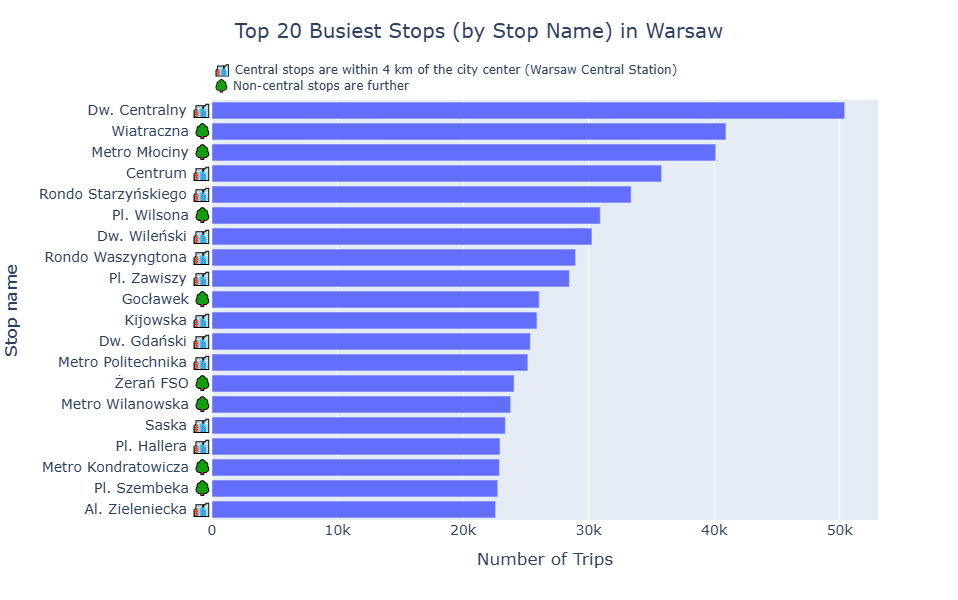

In [49]:
# creating a barplot to display the top stops
fig = px.bar(
    top_stops_aggregated,
    x='trips_count',
    y='stop_name_central_emoji',
    orientation='h',
    title='Top 20 Busiest Stops (by Stop Name) in Warsaw',
    labels={'trips_count': 'Number of Trips', 'stop_name_central_emoji': 'Stop name'},
    width=800,
    height=600,
    hover_name = 'stop_name_central_emoji',
    hover_data={                         # adding extra data to display at bars selection)
        'trips_count': True,
        'stop_name_central_emoji':False,
        'stop_lat': ':.4f', 
        'stop_lon': ':.4f' }) 

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title={'x': 0.5, 'y': 0.96}, font=dict(size=14))

fig.add_annotation(
    text='🏙️ Central stops are within 4 km of the city center (Warsaw Central Station) <br>🌳 Non-central stops are further',
    xref='paper', yref='paper', x=0, y=1.095,
    showarrow=False, font=dict(size=12), align='left')
fig.show();

<span style="font-size:1.19em;"><b>Observations</b></span>
  
- As we mentioned earlier, **a single stop name may correspond to multiple stop IDs** (representing different entrances or stops for various types of public transport).
- **When comparing the names** of the top 20 busiest stop IDs  with the top 20 busiest stop names (data aggregated by stop name), **we observe a shift in the leaders. However, the main stop names remain the same.**
- **Among the top 20 busiest stops (by stop name) 40% (8 out of 20) are non-central stops**, which are of special interest in this study. In particular **among the top three stations there are two non-central ones**.  

***Note:** In the boxplots above, stops are ranked by overall traffic (number of trips passing through the stations), without considering the types of transport and their passenger capacity.*


### 📍 Busiest Stops (Based on Weighted Capacity)

Above **we identified the most popular stops in general**. However, **this information is not entirely reliable for understanding actual passenger flow**, as we haven't distinguished between different types of transport, while each of them has a different passenger capacity.

⚠ In the next step **we will define and include in our calculations capacity weights by transport type.** We've already identified transport types operating in Warsaw (`fleet_type` column in the `trips_df`). Since getting precise data on their capacity is complicated *(if possible, as the vehicles names are not so clear, e.g. "G-np18m" or "2 wagony")*, we will follow a simplified approach - **we will set weights to each transport type. We will assign the bus a weight of 1 (as the base unit**, with an average capacity of 90 passengers). **Other types of transport will be assigned weights based on their approximate capacity relative to the bus**. For example, a tram, with an average capacity of 200 passengers, will be assigned a weight of 2.2 times that of the bus.

**Decisions on weights, based on our research**, are following: 

- **Buses** typically carry around **80-100 passengers**, we will treat as **90 passengers in average**.
    - We set buses as the base unit with a **bus weight - 1**.
- **Trams** in Warsaw can carry approximately **200 passengers**.
    - We set **tram weight - 2.2** (200/90)
- **Rail** (SKM and Other Suburban Trains). Suburban trains typically have capacities ranging from **1,000 to 1,200 passengers**, we will treat as **1100 passengers in average**.
    - We set **metro weight - 12.2** (1100/90)
- **Metro**. A standard metro train in Warsaw can hold about **1,500 passengers**.
    - We set **metro weight - 16.7** (1500/90)

***Note**: **The typical capacities of each transport type do not necessarily reflect their actual usage. However, these approach provide the best available estimation.** We will verify these figures against official statistics once we complete our calculations.*

In [54]:
"""
Our data:
    bus routes - 290 (route_type = 3)
    tram/light rail routes - 28 (route_type = 0)
    rail routes - 5 (route_type = 2)
    metro lines - 2 (route_type = 1)
"""

# creating a column with transport names (based on the `route_type`)
routes_df['transport_type'] = routes_df['route_type'].map({3: "Bus", 0: "Tram", 2: "Rail", 1: "Metro"})

# creating a column with transport weights
routes_df['transport_weight'] = routes_df['route_type'].map({3: 1, 0: 2.2, 2: 12.2, 1: 16.7})

routes_df.head(3)

'\nOur data:\n    bus routes - 290 (route_type = 3)\n    tram/light rail routes - 28 (route_type = 0)\n    rail routes - 5 (route_type = 2)\n    metro lines - 2 (route_type = 1)\n'

,route_id,agency_id,route_short_name,route_long_name,route_type,route_color,route_text_color,transport_type,transport_weight
0,1,0,1,Żerań Wschodni – P+R Al. Krakowska,0,B60000,FFFFFF,Tram,2.20
1,10,0,10,Os. Górczewska – Wyścigi,0,B60000,FFFFFF,Tram,2.20
2,102,0,102,Metro Stadion Narodowy – PKP Olszynka Grochowska,3,880077,FFFFFF,Bus,1.00


**Let's join the DataFrames** to obtain information about stops, routs, transport and transport weights altogether in the same DataFrame.

In [73]:
# joining the DataFrames 
trips_with_routes = pd.merge(trips_df, routes_df[['route_id', 'route_type', 'transport_type','transport_weight']], on='route_id') # getting data about routs and transport weights
stop_times_with_routes = pd.merge(stop_times_df, trips_with_routes[['trip_id', 'route_type','transport_type','transport_weight']], on='trip_id') # combining with data about stops
stop_times_with_names_with_routes = pd.merge(stop_times_with_routes, stops_df[['stop_id', 'stop_name', 'stop_name_central_emoji', 'stop_lat', 'stop_lon']], on='stop_id') # enhancing data with stops descriptions
stop_times_with_names_with_routes.sample(3, random_state=10)

MemoryError: Unable to allocate 58.9 MiB for an array with shape (7722163,) and data type int64

In [ ]:
# aggregating data by `stop_name`
aggregated_stops = stop_times_with_names_with_routes.groupby(['stop_name', 'stop_name_central_emoji']).agg(
    unique_stop_ids=('stop_id', 'unique'), # a list of unique stop ids associated with the same stop name
    unique_stop_ids_count=('stop_id', 'nunique'), # number of unique stop ids associated with the same stop name
    route_types=('route_type', lambda x: list(x.unique())), # a list of unique route types
    transport_types=('transport_type', lambda x: list(x.unique())),  #  a list of unique transport types
    transport_weight_mean=('transport_weight', 'mean'),
    stop_lat_mean=('stop_lat', 'mean'),
    stop_lon_mean=('stop_lon', 'mean'),
    trips_count=('stop_name', 'size'),
    weighted_trips_capacity=('transport_weight', 'sum')  # weighted impact of each stop (given the passengers capacity of transport serving that stop)
).reset_index()

aggregated_stops.sample(3)

In [ ]:
# sorting by weighted count to identify top stops
top_weighted_stops = aggregated_stops.sort_values('weighted_trips_capacity', ascending=False).head(20)
print("\n\033[1mTop 20 stops by weighted capacity:\033[0m")
top_weighted_stops

In [ ]:
# creating a barplot to display the top stops
fig = px.bar(
    top_weighted_stops,
    x='weighted_trips_capacity',
    y='stop_name_central_emoji',
    orientation='h',
    title='Top 20 Busiest Stops (by Stop Name and Weighted Trips Capacity) in Warsaw',
    labels={'weighted_trips_capacity': 'Weighted Trips Capacity', 'stop_name_central_emoji': 'Stop name'},
    width=800,
    height=600,
    hover_name = 'stop_name_central_emoji',
    hover_data={                         # adding extra data to display at bars selection)
        'trips_count': True,
        'unique_stop_ids_count': True,
        'stop_name_central_emoji':False,
        'stop_lat_mean': ':.4f', 
        'stop_lon_mean': ':.4f' }) 

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title={'x': 0.5, 'y': 0.96}, font=dict(size=14),
    margin=dict(b=105))  # increasing bottom margin for the annotation placement

fig.add_annotation(
    text='<b>🏙️ Central stops</b> are within 4 km of the city center (Warsaw Central Station) <br><b>🌳 Non-central</b> stops are further',
    xref='paper', yref='paper', x=0, y=1.095,
    showarrow=False, font=dict(size=12), align='left')

fig.add_annotation(
    text='<i><b>Note:</b> Weighted Trips Capacity takes into account both trips volume <br>and passengers capacity of different transport serving each stop.</i>',
    xref='paper', yref='paper', x=0, y=-0.25,
    showarrow=False, font=dict(size=12), align='left')
    
fig.show();

Also, **let's examine how many of the top 20 busiest stops by weighted capacity are the same with the top 20 busiest stops by overall transport traffic (without applying weights).**

In [ ]:
# getting lists of top 20 stops in each group
top_20_stops = top_stops_aggregated['stop_name'].to_list()
top_20_stops_weighted = top_weighted_stops['stop_name'].to_list()

In [ ]:
# checking common stops
common_stops = set(top_20_stops).intersection(set(top_20_stops_weighted))
number_of_common_stops = len(common_stops)
share_of_common_stops = number_of_common_stops / 20

print(f'\033[1mThe percentage of stops that appear in both the top 20 busiest stops (overall traffic)\033[0m '
      f'\033[1mand the top 20 busiest stops (weighted capacity) is: {share_of_common_stops:0.1%}.\033[0m')
print(f'\033[1m{number_of_common_stops} out of 20 stops remain the same in both rankings.\033[0m')

Here we come to one of the most important parts of the project - visualizing our analysis on the map. **We will create a heatmap to highlight the busiest areas in Warsaw, using `weighted_trips_capacity` values to indicate the top spots**. For this visualization, **we are using aggregated stops (without distinguishing by transport type)**. Additionally, for each stop, we will demonstrate the number of unique stops it represents, the transport types it serves, and the total trips count passing through the stop.

In [ ]:
def create_warsaw_map_aggregated(aggregated_stops, title="Warsaw Public Transport Traffic Map"):
    """
    The function creates an interactive map of Warsaw with heatmap and markers representing public transport stops.
    
    Parameters:
     - aggregated_stops (DataFrame): DataFrame containing stop information 
     - title (str): title displayig on the map
    
    Returns:
    - folium.Map
    
    ----------
    Notes:
     - for proper functioning the aggregated_stops must contain: `stop_lon_mean`, `stop_lat_mean` and `weighted_trips_capacity`, `stop_name`, `transport_types`, `unique_stop_ids_count`, `trips_count` columns.
     - for proper functioning there must be no missing values in the `stop_lon_mean` and `stop_lat_mean` columns.
    """

    city_center = (52.2319, 21.0067)  # latitude and longitude of Warsaw Central Station 
    
    # creating a map centered on Warsaw Central Station 
    warsaw_map = folium.Map(location=city_center, zoom_start=12, tiles='CartoDB positron') #using light-themed map style

    # preparing data 
    heat_data = []
    seen_coords = set()

    for _, row in aggregated_stops.iterrows(): # looping over each row, ignoring indexes returned by iterrows()        
        # creating a tuple of coordinates (we round the coordinates for comparison)
        coord_key = (round(row['stop_lat_mean'], 6), round(row['stop_lon_mean'], 6))
        
        # adding each points only if we haven't seen its coordinates before
        if coord_key not in seen_coords:
            heat_data.append([
                row['stop_lat_mean'], 
                row['stop_lon_mean'], 
                row['weighted_trips_capacity']])            
            seen_coords.add(coord_key)

    # setting max `weighted_trips_capacity` value for proper scaling
    max_weight = max(point[2] for point in heat_data)

    # creating a heatmap layer 
    heatmap = HeatMap(
        heat_data,
        min_opacity=0.2,
        max_val=max_weight,
        radius=15, 
        blur=15, 
        gradient={'0.4': 'blue', '0.65': 'lime', '0.9': 'orange', '1.0': 'red'}) # converting float keys to strings to avoid AttributeError

    # adding the heatmap to the folium map
    heatmap.add_to(warsaw_map)

    # creating a marker cluster groups (for interactive points of our transport stops)
    marker_cluster = MarkerCluster().add_to(warsaw_map)    
    seen_coords = set()  # resetting the set for markers
    

    for _, row in aggregated_stops.iterrows():        
        coord_key = (round(row['stop_lat_mean'], 6), round(row['stop_lon_mean'], 6))   
        
        # adding each points only if we haven't seen its coordinates before
        if coord_key not in seen_coords:        
            
            # creating popup HTML without Transport Weight Mean
            popup_text = f"""
            <b>Stop Name:</b> {row['stop_name']}<br>
            <b>Transport Types:</b> {', '.join(str(t) for t in row['transport_types'])}<br>
            <b>Unique Stop IDs Count:</b> {row['unique_stop_ids_count']}<br>
            <b>Trips Count:</b> {row['trips_count']}<br>
            <b>Weighted Trips Capacity:</b> {row['weighted_trips_capacity']:0.0f}
            """
            
            # creating marker and adding directly to cluster
            folium.Marker(
                location=[row['stop_lat_mean'], row['stop_lon_mean']],
                popup=folium.Popup(popup_text, max_width=300),
                icon=folium.Icon(icon='info-sign')).add_to(marker_cluster)
            
            seen_coords.add(coord_key)

    # adding a title to the map (setting high z-index to display the title on top of most other elements)
    title_html = f'''
    <div style="position: fixed; 
                top: 5px; left: 50%; transform: translateX(-50%);
                z-index:9999; font-size:14px; font-weight: bold; 
                background-color:rgba(255, 255, 255, 0.8); 
                padding: 5px 10px;
                border-radius: 5px; box-shadow: 0 0 2px rgba(0,0,0,0.1);">
        {title}
    </div>
    '''
    
    warsaw_map.get_root().html.add_child(folium.Element(title_html)) # get_root() method extracts base structure of the map (tiles, markers, etc.) and .add_child() inserts the title into the map

    # adding the legend for heatmap 
    legend_html = '''
    <div style="position: fixed; 
                bottom: 20px; right: 10px; width: 190px; height: 105px; 
                border:2px solid grey; z-index:9998; font-size:12px;
                background-color: rgba(255, 255, 255, 0.8);
                padding: 5px;
                border-radius: 5px;">
        <p style="margin-top: 0;"><b>Heatmap Intensity Scale</b></p>
        <div style="display: flex;">
            <div style="flex-grow: 1; background: linear-gradient(to right, blue, lime, orange, red); height: 15px;"></div>
        </div>
        <div style="display: flex; justify-content: space-between;">
            <span>Low</span>
            <span>Medium</span>
            <span>High</span>
        </div>
        <p style="margin-bottom: 0; font-size: 11px;">Based on Weighted Trips Capacity</p>
        <p style="margin-bottom: 0; font-size: 11px;">Max value: ''' + str(int(max_weight)) + '''</p>
    </div>
    '''

    # adding the legend as an html element to the map
    warsaw_map.get_root().html.add_child(folium.Element(legend_html)) 

    # adding a note under the title section
    note_html = '''
    <div style="position: fixed; 
                bottom: 20px; left: 50%; transform: translateX(-50%);
                z-index:9997; font-size:12px; font-style: italic;
                background-color: rgba(255, 255, 255, 0.8); 
                padding: 5px 10px;
                border-radius: 5px; box-shadow: 0 0 2px rgba(0,0,0,0.1);">
        <b>Note:</b> Weighted Trips Capacity takes into account both trips volume and passengers capacity of different transport serving each stop.
    </div>
    '''    
    warsaw_map.get_root().html.add_child(folium.Element(note_html))     
    return warsaw_map

# finally creating and launching the map
warsaw_map = create_warsaw_map_aggregated(aggregated_stops.sort_values(by='weighted_trips_capacity', ascending=False).head(10))
warsaw_map

#warsaw_map.save('warsaw_heatmap.html')

### 🚩 Public Transport Hubs

We've already noticed that there are **38 stops identified as transport hubs based on the `location_type` column in the `stops_df` DataFrame** (where `location_type` == 1). **However, we can't directly evaluate their importance** (since stops with `location_type` = 1 lack specific arrival or departure times and are not included in the `stop_times_df` DataFrame).

In [ ]:
# filtering places with multiple platforms or multiple stops (according to the `location_type` column of the `stops_df`)
central_stops = stops_df.query('location_type == 1')

print(f'\033[1mNumber of central stops (`location_type` = 1 in the `stops_df` DataFrame):\033[0m {len(central_stops)}\n')
central_stops.head()

At the same time, we observed that **some stops are served by multiple types of public transport** (multiple `transport_types` values in the `aggregated_stops` DataFrame). **This data allows us access measurable impact of these hubs** (e.g. by `weighted_trips_capacity`).  Let's examine those stops (data aggregated by `stop_name` column) having more than one transport type and those having more than two - they must be **the main transport hubs**. 

In [ ]:
# filtering stops with multiple transport types
multi_transport_stops = aggregated_stops[aggregated_stops['transport_types'].apply(lambda x: len(x) > 1)].sort_values(by='weighted_trips_capacity', ascending=False)

print(f'\033[1mNumber of stops with multiple transport types:\033[0m {len(multi_transport_stops)}\n')
multi_transport_stops.head()

In [ ]:
# filtering stops with more than two transport types
multi_transport_stops_2 = aggregated_stops[aggregated_stops['transport_types'].apply(lambda x: len(x) > 2)]

print(f'\033[1mNumber of stops with with more than two transport types:\033[0m {len(multi_transport_stops_2)}')
multi_transport_stops_2.head()

### ✔️ Verification of Weighted Impact Calculations

**Let's calculate the weighted impact of each transport type on the overall performance**. Once the calculations are completed, we can **compare the result with the official statistics** *(we provided them in the Warsaw Public Transport Overview in the project beginning)*. To do this, we will first **aggregate data by stop name AND transport type**. 

***Note** Here we also group by `stop_name` as the DataFrame we create will be later used for analysis of stops traffic by transport type.* 

In [ ]:
# aggregating data by `stop_name`
aggregated_stops_by_transport = stop_times_with_names_with_routes.groupby(['stop_name', 'stop_name_central_emoji', 'transport_type', 'transport_weight']).agg(
    unique_stop_ids=('stop_id', 'unique'), # a list of unique stop ids associated with the same stop name
    unique_stop_ids_count=('stop_id', 'nunique'), # number of unique stop ids associated with the same stop name       
    stop_lat_mean=('stop_lat', 'mean'),
    stop_lon_mean=('stop_lon', 'mean'),
    trips_count=('stop_name', 'size'),
    weighted_trips_capacity=('transport_weight', 'sum')  # weighted impact of each stop (given the passengers capacity of transport serving that stop)
).reset_index().sort_values(by='weighted_trips_capacity', ascending=False)

aggregated_stops_by_transport.sample(3)

In [ ]:
# calculating summary on the weighted impact of each transport type
transport_weighted_totals = aggregated_stops_by_transport.groupby('transport_type')['weighted_trips_capacity'].sum().reset_index()
transport_weighted_totals['share'] = transport_weighted_totals['weighted_trips_capacity'] / transport_weighted_totals['weighted_trips_capacity'].sum()
transport_weighted_totals

In [ ]:
# plotting pie chart of weighted trips by transport type
transport_labels = transport_weighted_totals['transport_type'].to_list()

plt.figure(figsize=(5, 5))
plt.pie(
    transport_weighted_totals['weighted_trips_capacity'],
    labels=transport_labels,
    autopct='%1.1f%%',  
    startangle=90,
    shadow=False,  
    colors=sns.color_palette('pastel'))

plt.title('Distribution of Weighted Trips by Transport Type in Warsaw', fontsize=14)
plt.tight_layout()
plt.show();

After recognizing the absence of metro data in the GTFS dataset, we decided to proceed. While **we cannot directly compare the impact of transport types from our weighted calculations with official statistics, we can analyze proportions**, for example, by comparing the bus to tram ratio in our calculations to that in the official data.

In [ ]:
# calculating bus to tram ratios
bus_to_tram_official_stats = 403032807 / 247221160
bus_to_tram_weighted_calc = (transport_weighted_totals.query('transport_type == "Bus"')['weighted_trips_capacity'].sum() 
                             / transport_weighted_totals.query('transport_type == "Tram"')['weighted_trips_capacity'].sum())

# calculating bus to rail ratios
bus_to_rail_official_stats = 403032807 / (17760180 + 30955295 + 3657416) # since the SKM (Suburban Railway) operates like a rail system and is part of Warsaw's broader suburban rail network, it falls under the rail routes category (route_type = 2), not the light rail/tram category. Warsaw Commuter Railway (WKD - Warszawska Kolej Dojazdowa) should be classified under rail routes (route_type = 2), similar to SKM.
bus_to_rail_weighted_calc = (transport_weighted_totals.query('transport_type == "Bus"')['weighted_trips_capacity'].sum() 
                             / transport_weighted_totals.query('transport_type == "Rail"')['weighted_trips_capacity'].sum())

# calculating percentage difference
bus_to_tram_diff = abs((bus_to_tram_weighted_calc - bus_to_tram_official_stats) / bus_to_tram_official_stats) * 100
bus_to_rail_diff = abs((bus_to_rail_weighted_calc - bus_to_rail_official_stats) / bus_to_rail_official_stats) * 100

print(f'Bus to Tram Ratio (Official Statistics): {bus_to_tram_official_stats:.2f}')
print(f'Bus to Tram Ratio (Weighted Calculation): {bus_to_tram_weighted_calc:.2f}')
print(f'Percentage Difference: {bus_to_tram_diff:.2f}%')
print("-"*50)
print(f'Bus to Rail Ratio (Official Statistics): {bus_to_rail_official_stats:.2f}')
print(f'Bus to Rail Ratio (Weighted Calculation): {bus_to_rail_weighted_calc:.2f}')
print(f'Percentage Difference: {bus_to_rail_diff:.2f}%')

<span style="font-size:1.19em;"><b>Observations</b></span>  

⚠ **The calculated proportions are quite close to the official statistics**, with differences of 2% (bus to tram) and 31% (bus to rail). Where **bus to tram metric is much more meaning for us**, since trams represent about 29% of overall traffic while railway transport collectively just for about 6% of overall traffic *(thus being much more sensitive for ratio calculation)*. Therefore, our **weighted impact estimations appear reliable enough to trust the analysis and proceed further**.

### 📍 Busiest Stops by Transport Type (Based on Weighted Capacity)

Now we will sort `aggregated_stops_by_transport` to identify top stops.

In [ ]:
# sorting by weighted count to identify top stops
top_weighted_stops_by_transport = (aggregated_stops_by_transport.query('stop_name in @top_20_stops_weighted') # filtering top 20 busiest stops (by weighted capacity)
                                   .sort_values('weighted_trips_capacity', ascending=False))

print('\n\033[1mTop 20 stops (by weighted capacity) with differentiation by transport type:\033[0m')
top_weighted_stops_by_transport

**Let's plot a bar chart showing commutative impact of each transport type to stops overall traffic**. *This time, we'll again benefit from Plotly's library, providing great interactivity for visualizations.*

In [ ]:
# creating a bar plot showing the cumulative impact of each transport type
fig = px.bar(
    top_weighted_stops_by_transport,
    x='weighted_trips_capacity',
    y='stop_name_central_emoji',
    color='transport_type',
    orientation='h',
    title='Top 20 Busiest Stops by Transport Type (by Stop Name and Weighted Trips Capacity) in Warsaw',
    labels={'weighted_trips_capacity': 'Weighted Trips Capacity', 'stop_name_central_emoji': 'Stop Name', 'transport_type':'Transport Type'},
    width=800,
    height=600,
    # category_orders={'stop_name_central_emoji': top_weighted_stops_by_transport},  # sorting bars in the needed order   
    hover_name = 'stop_name_central_emoji',
    hover_data={                         # adding extra data to display at bars selection)
        'trips_count': True,
        'unique_stop_ids_count': True,
        'stop_name_central_emoji':False,
        'stop_lat_mean': ':.4f', 
        'stop_lon_mean': ':.4f' }) 
         
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    title={'x': 0.5, 'y': 0.96}, font=dict(size=14),
    margin=dict(b=105))  # increasing bottom margin for the annotation placement) )

fig.add_annotation(
    text='🏙️ <b>Central stops</b> are within 4 km of the city center (Warsaw Central Station) <br>🌳 <b>Non-central</b> stops are further',
    xref='paper', yref='paper', x=0, y=1.095,
    showarrow=False, font=dict(size=12), align='left')

fig.add_annotation(
    text='<i><b>Note:</b> Weighted Trips Capacity takes into account both trips volume <br>and passengers capacity of different transport serving each stop.</i>',
    xref='paper', yref='paper', x=0, y=-0.25,
    showarrow=False, font=dict(size=12), align='left')

#pio.write_html(fig, file='Top Stops by Transport Type (Bar Plot).html', auto_open=True)
fig.show();

Now **we will create a heatmap similar to the previous one but with additional enhancements**. It will again **highlight the busiest areas in Warsaw, using `weighted_trips_capacity` values**. However, this time, **it will also show the impact of each transport type on overall traffic**.

Additionally, we **will explicitly indicate transport hubs** - stations served by two or more transport types *(While transport flows through a station do not necessarily mean passengers will enter or exit there, the presence of multiple transport types **increases the likelihood of passengers visiting these stops** due to line changes).*

The map will allow us to **select whether to display each transport type and transport hubs.**

In [ ]:
def create_warsaw_map_by_transport(aggregated_stops_by_transport, multi_transport_stops, title='Warsaw Traffic Map by Public Transport Type'):
    """
    The function creates an interactive map of Warsaw with heatmap and markers differentiated by transport type.
    
    Parameters:
     - aggregated_stops_by_transport (DataFrame): DataFrame containing stop information with transport types
     - multi_transport_stops (DataFrame): DataFrame containing stops that are transportation hubs (serving two and more thasport types)   
     - title (str): title displayig on the map
    
    Returns:
     - folium.Map
    
    Notes:
     - for proper functioning the aggregated_stops_by_transport and multi_transport_stops must contain: `stop_lon_mean`, `stop_lat_mean` and `weighted_trips_capacity`, `stop_name`, `transport_types`, `unique_stop_ids_count`, `trips_count` columns.
     - for proper functioning there must be no missing values in the `stop_lon_mean` and `stop_lat_mean` columns.
    """
    
    city_center = (52.2319, 21.0067)  # latitude and longitude of Warsaw Central Station 
    
    # creating a map centered on Warsaw Central Station 
    warsaw_map = folium.Map(location=city_center, zoom_start=12, tiles='CartoDB positron') #using light-themed map style
   
    # preparing data 
    heat_data = []
    seen_coords = set()
    
    for _, row in aggregated_stops_by_transport.iterrows(): # looping over each row, ignoring indexes returned by iterrows()  
        coord_key = (round(row['stop_lat_mean'], 6), round(row['stop_lon_mean'], 6))
        
          # adding each points only if we haven't seen its coordinates before
        if coord_key not in seen_coords:
            heat_data.append([
                row['stop_lat_mean'], 
                row['stop_lon_mean'], 
                row['weighted_trips_capacity']]) 
            seen_coords.add(coord_key)

    # setting max `weighted_trips_capacity` value for proper scaling
    max_weight = max(point[2] for point in heat_data)

    # creating a heatmap layer 
    heatmap = HeatMap(
        heat_data,
        min_opacity=0.2,
        max_val=max_weight,
        radius=15, 
        blur=15, 
        gradient={'0.4': 'blue', '0.65': 'lime', '0.9': 'orange', '1.0': 'red'}, # converting float keys to strings to avoid AttributeError
        name='Weighted Trips Capacity Heatmap')

    # adding the heatmap to the folium map
    heatmap.add_to(warsaw_map)

    # defining icons for each transport type
    transport_icons = {
        'Bus': 'bus',
        'Tram': 'tram',
        'Metro': 'subway',
        'Rail': 'train'}
        
    # defining colors for each transport type
    transport_colors = {
        'Bus': 'blue',
        'Tram': 'green',
        'Metro': 'red',
        'Rail': 'purple'}

    # creating a marker cluster groups (for interactive points of our transport stops)
    marker_clusters = {}
    for transport_type in aggregated_stops_by_transport['transport_type'].unique():
        marker_clusters[transport_type] = MarkerCluster(name=f"{transport_type} Stops").add_to(warsaw_map)

    for _, row in aggregated_stops_by_transport.iterrows():
        # getting appropriate icons for transport type
        transport_type = row['transport_type']
        icon_name = transport_icons.get(transport_type, 'info-sign')
        icon_color = transport_colors.get(transport_type, 'blue')
        
        # creating popup HTML
        popup_text = f"""
        <b>Stop Name:</b> {row['stop_name']}<br>
        <b>Transport Type:</b> {transport_type}<br>
        <b>Unique Stop IDs Count:</b> {row['unique_stop_ids_count']}<br>
        <b>Trips Count:</b> {row['trips_count']}<br>
        <b>Transport Weight:</b> {row['transport_weight']}<br>
        <b>Weighted Trips Capacity:</b> {row['weighted_trips_capacity']:.0f}
        """
        
        # creating marker and adding directly to appropriate cluster
        folium.Marker(
            location=[row['stop_lat_mean'], row['stop_lon_mean']],
            popup=folium.Popup(popup_text, max_width=300),
            icon=folium.Icon(icon=icon_name, prefix='fa', color=icon_color)
        ).add_to(marker_clusters[transport_type])
    
    # creating a new feature group for transportation hubs
    transport_hubs_layer = folium.FeatureGroup(name="Transportation Hubs 🚩", show=True).add_to(warsaw_map)

    # adding markers for multi-transport stops
    for _, hub in multi_transport_stops.iterrows():
        # Create popup HTML for the hub
        hub_popup_text = f"""
        <b>Hub Name:</b> {hub['stop_name']}<br>
        <b>Transport Types:</b> {hub['transport_types']}<br>
        <b>Unique Stop IDs Count:</b> {hub['unique_stop_ids_count']}<br>
        <b>Trips Count:</b> {hub['trips_count']}<br>
        <b>Weighted Trips Capacity:</b> {hub['weighted_trips_capacity']:.0f}
        """
        
        # creating special icon for hubs
        hub_icon = folium.DivIcon(
            icon_size=(20, 20),
            icon_anchor=(10, 10),
            html=f'<div style="font-size: 18px; color: black;">🚩</div>')
        
        # adding marker to the hubs layer
        folium.Marker(
            location=[hub['stop_lat_mean'], hub['stop_lon_mean']],
            popup=folium.Popup(hub_popup_text, max_width=300),
            icon=hub_icon
        ).add_to(transport_hubs_layer)

    # adding a title to the map
    title_html = f'''
    <div style="position: fixed; 
                top: 5px; left: 50%; transform: translateX(-50%);
                z-index:9999; font-size:14px; font-weight: bold;
                background-color: rgba(255, 255, 255, 0.8); 
                padding: 5px 10px;
                border-radius: 5px; box-shadow: 0 0 2px rgba(0,0,0,0.1);">
        {title}
    </div>
    '''
    
    warsaw_map.get_root().html.add_child(folium.Element(title_html))

    # adding custom legend for heatmap intensity
    legend_html = '''
    <div style="position: fixed; 
                bottom: 20px; right: 10px; width: 190px; 
                border:2px solid grey; z-index:9998; font-size:12px;
                background-color: rgba(255, 255, 255, 0.8); 
                padding: 5px;
                border-radius: 5px;">
        <p style="margin-top: 0;"><b>Heatmap Intensity Scale</b></p>
        <div style="display: flex;">
            <div style="flex-grow: 1; background: linear-gradient(to right, blue, lime, orange, red); height: 15px;"></div>
        </div>
        <div style="display: flex; justify-content: space-between;">
            <span>Low</span>
            <span>Medium</span>
            <span>High</span>
        </div>
        <p style="margin-bottom: 0; font-size: 11px;">Based on Weighted Trips Capacity</p>
        <p style="margin-bottom: 0; font-size: 11px;">Max value: ''' + str(int(max_weight)) + '''</p>
    </div>
    '''

    # adding the legend as an html element to the map
    warsaw_map.get_root().html.add_child(folium.Element(legend_html))
    
    # adding transport type legend
    transport_legend_html = '''
    <div style="position: fixed; 
                bottom: 20px; left: 10px; width: 150px;
                border:2px solid grey; z-index:9998; font-size:12px;
                background-color: rgba(255, 255, 255, 0.8); 
                padding: 5px;
                border-radius: 5px;">
        <p style="margin-top: 0;"><b>Transport Types</b></p>
        <div style="display: flex; align-items: center; margin: 3px 0;">
            <i class="fa fa-bus" style="color: blue; width: 20px; text-align: center;"></i>
            <span style="margin-left: 5px;">Bus</span>
        </div>
        <div style="display: flex; align-items: center; margin: 3px 0;">
            <i class="fa fa-tram" style="color: green; width: 20px; text-align: center;"></i>
            <span style="margin-left: 5px;">Tram</span>
        </div>
        <div style="display: flex; align-items: center; margin: 3px 0;">
            <i class="fa fa-subway" style="color: red; width: 20px; text-align: center;"></i>
            <span style="margin-left: 5px;">Metro</span>
        </div>
        <div style="display: flex; align-items: center; margin: 3px 0;">
            <i class="fa fa-train" style="color: purple; width: 20px; text-align: center;"></i>
            <span style="margin-left: 5px;">Rail</span>
        </div>
        <div style="display: flex; align-items: center; margin: 3px 0;">
            <div style="color: black; width: 20px; text-align: center;">🚩</div>
            <span style="margin-left: 5px;">Transport Hubs</span>
        </div>
    </div>
    '''

    warsaw_map.get_root().html.add_child(folium.Element(transport_legend_html))
    
    # adding a note under the title section
    note_html = '''
    <div style="position: fixed; 
                bottom: 20px; left: 50%; transform: translateX(-50%);
                z-index:9997; font-size:12px; font-style: italic;
                background-color: rgba(255, 255, 255, 0.8); 
                padding: 5px 10px;
                border-radius: 5px; box-shadow: 0 0 2px rgba(0,0,0,0.1);">
        <b>Note:</b> Weighted Trips Capacity takes into account both trips volume and passengers capacity of different transport serving each stop.
    </div>
    '''  
    warsaw_map.get_root().html.add_child(folium.Element(note_html)) 
    
    # adding layer control to choose whether to display different transport types and transport hubs
    folium.LayerControl().add_to(warsaw_map)
    
    return warsaw_map

# finally creating and launching the map
warsaw_map = create_warsaw_map_by_transport(aggregated_stops_by_transport, multi_transport_stops, title="Warsaw Traffic by Transport Type")
warsaw_map

#warsaw_map.save('warsaw_transport_map.html')

## 🎯 Project Summary

- **Accomplished Analysis**
    - **Data sources we used**:  We analyzed public transport data using reliable sources, including **official reports from Warsaw's transport authorities** (e.g., ZTM Report 2022). Our main dataset was **GTFS data for Warsaw**, last updated on **January 18, 2025**. This data, covering a two month period, was considered accurate and sufficient for our study.
      
    - **Checking data quality and preparation for further analysis**: We checked the data and no critical issues like duplicates or missing values in key fields were revealed. However, we noted a **lack of comprehensive metro data**, as only a few records were included. Necessary table merges were performed to link and prepare the data for analysis. 
      
    - **Passenger flow estimation**: To better represent traffic, we calculated **weighted trips capacity** by combining trip counts with **average transport capacity per type**. We verified our approach by comparing our figures with the official statistics, they align pretty well.    
    - **Visualizations**:
        - We identified the busiest stops and displayed them in interactive **bar plots** showing:  
           - **Trips count per stop id**.
           - **Trips count per stop name** *(that may contain several stop ids).*
           - **Weighted trips capacity per stop name**. 
           - **Weighted trips capacity per stop name by transport type**.           
           - We **highlighted non-central stations**, as we focused on them (we defined central stations as those within 4 km from Warsaw Central Railway station and distinguished them from others). Thanks to Plotly library, these visualizations are very interactive and allow to explore additional details associated with each stop (like transport types, coordinates and trips number).
    
        - Two detailed **interactive maps** were created using Folium:
            - The **heatmap** showing weighted trips capacity and overall information on stops **without separation by transport types**.
                - This map is **best for visualizing aggregated passenger flows** (regardless of transport types) **and high-traffic areas**.
            - The **layered map** visualizing how **different transport types** contribute to traffic. It also explicitly demonstrates **transport hubs** *(stations served by two or more transport types, that likely demonstrate higher passenger activity).*
                - This map is **best for analyzing how each transport type contributes to overall traffic**, it also **highlights transport hubs** (stations with multiple transport types) that tend to **have higher passenger activity** because of their connections.    

- **Next Steps**   
    - **Addressing metro data gaps**: The GTFS data we used lacks metro coverage. We can retrieve data from platforms like the [Warsaw Open Data Portal](https://api.um.warszawa.pl/) or directly from metro authorities (if possible). This would improve our passenger flow estimates by about 19% (based on official metro traffic stats).
      
    - **Time-based analysis**: GTFS data allows us to analyze traffic by time intervals, revealing daily and hourly trends. We can make needed calculations and add temporal layer to our analyses (even on the heatmaps) this would help better choose pizzeria locations and operating hours.
       
    - **Adding car traffic**: We found reliable traffic data from the **Municipal Roads Authority (2022)** ([link here](https://zdm-warszawa.maps.arcgis.com/apps/dashboards/)). Including this data would provide another layer for insights on people flows.

## 📋 References

- **Official reports**
    1.  [**ZTM Report 2022**](https://ppl-ai-file-upload.s3.amazonaws.com/web/direct-files/17236753/e887557c-8634-4952-8901-c5f86913e9a7/ZTM_raport_2022.pdf) - This is the original report by the Public Transport Authority (Zarząd Transportu Miejskiego) detailing Warsaw's public transportation system's performance and statistics for 2022.
    2.  [**WARSAW PUBLIC TRANSPORT AUTHORITY, REPORT 2022**](https://web.archive.org/web/20240216194613/https://www.ztm.waw.pl/wp-content/uploads/2023/04/raport_ZTM_2022popr.pdf) *(Archived version; the original site `ztm.waw.pl` was unavailable during the study)* - This is the revised report by the Public Transport Authority (Zarząd Transportu Miejskiego) for 2022.
        *Note: The archived version has "popr" in the filename, indicating "poprawiony" (corrected) in Polish, suggesting that this report might be a revised version of the original.*
    3.  [**ANNUAL REPORT: PUBLIC ROADS AUTHORITY IN WARSAW 2022**](https://zdm.waw.pl/wp-content/uploads/2023/06/Raport-ZDM_2022__ENG__FINAL-czytniki.pdf) - This report by the Public Roads Authority in Warsaw (ZDM - Zarząd Dróg Miejskich) provides information about road infrastructure, traffic management, and related data within Warsaw for 2022.
    4.  [**MUNICIPAL ROADS AUTHORITY - Automatic Traffic Measurement Results (2022)**](https://zdm-warszawa.maps.arcgis.com/apps/dashboards/) - This interactive map and set of tables presents average daily vehicle traffic data for 2022, as provided by the Municipal Roads Authority.
       

- **Data sources**

    5.  [**GTFS Data for Warsaw (mkuran.pl)**](https://mkuran.pl/gtfs/) - GTFS (General Transit Feed Specification) data for Warsaw, providing a standardized format for public transportation schedules and related geographic data.
    6.  [Warsaw open data portal](https://api.um.warszawa.pl/) *(Not directly utilized in this study but highlighted as a valuable resource for future analyses)* - The official Warsaw open data portal that offers various datasets related to the city.



- **Public transport operators and company websites**

    7.  [**The website of the Office of Rail Transport (Strona Urzędu Transportu Kolejowego)**](https://utk.gov.pl/) - The official website of the Office of Rail Transport in Poland, offering information about rail transport regulations and statistics.
    8.  [**City of Warsaw’s official portal - Urban Transport**](https://en.um.warszawa.pl/urban-transport) - The official website of the City of Warsaw that provides information about urban transport services.
    9.  [**Metro Warszawskie - Company Profile, including expansion plans**](https://metro.waw.pl/metro-warszawskie/informacje-o-taborze/) - A section of the official Warsaw Metro website offering company information, including rolling stock details and expansion plans.
    10. [**Metro Warszawskie Sp. z o. o - Official Website**](https://metro.waw.pl/metro-warszawskie) - The official website of the Warsaw Metro operator.


- **Research and studies on public transport in warsaw**

    11. [**Analysis of Accessibility of Public Transport in Warsaw in the Opinion of Users**](https://lumenpublishing.com/journals/index.php/po/article/view/4024/3157) - A research paper analyzing the accessibility of public transport in Warsaw based on user feedback.
    12. [**Study: Measuring Dynamic Public Transit Accessibility to Local Centres in Warsaw**](https://www.researchgate.net/publication/326740543_Measuring_dynamic_public_transit_accessibility_to_local_centres_in_Warsaw/download?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6Il9kaXJlY3QiLCJwYWdlIjoiX2RpcmVjdCJ9fQ) - A study measuring dynamic public transit accessibility to local centers in Warsaw.



- **Wikipedia and general reference pages**

    13. [**General Transit Feed Specification**](https://gtfs.org/documentation/schedule/reference/?utm_source=chatgpt.com) - The official documentation for the General Transit Feed Specification (GTFS).
    14. [**Wikipedia: Warsaw Public Transport**](https://en.wikipedia.org/wiki/Warsaw#Transport) 
    15. [**Wikipedia: Warsaw Metro**](https://en.wikipedia.org/wiki/Warsaw_Metro) 
    16. [**Wikipedia: Transport in Warsaw**](https://en.wikipedia.org/wiki/Transport_in_Warsaw)

***Note:** Some of the sources may require a VPN with the country set to Poland to access them. And some sources may require translation from Polish.*
